In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, mean_squared_error, r2_score
from sklearn.preprocessing import LabelEncoder


In [2]:
# load dataset
df = pd.read_csv("/content/Titanic-Dataset.csv")

# select required columns
df = df[['Survived','Pclass','Sex','Age','SibSp','Parch','Fare','Embarked']]

# handle missing values
df['Age'] = df['Age'].fillna(df['Age'].mean())
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

# encode categorical data
le = LabelEncoder()
df['Sex'] = le.fit_transform(df['Sex'])
df['Embarked'] = le.fit_transform(df['Embarked'])

X = df.drop('Survived', axis=1)
y = df['Survived']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [3]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)

print("accuracy:", accuracy_score(y_test, y_pred))


accuracy: 0.8100558659217877


Pclass : 0.08743576493264185
Sex : 0.2708861549385469
Age : 0.24956986949384177
SibSp : 0.053530540906753084
Parch : 0.04099075105166422
Fare : 0.2633496619783479
Embarked : 0.03423725669820449


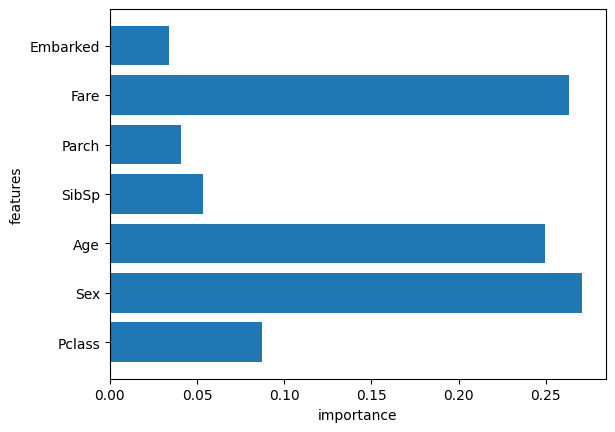

In [4]:
importance = rf.feature_importances_

for col, imp in zip(X.columns, importance):
    print(col, ":", imp)

# visualization
plt.barh(X.columns, importance)
plt.xlabel("importance")
plt.ylabel("features")
plt.show()


In [5]:
rf_tuned = RandomForestClassifier(
    n_estimators=200,
    max_depth=5,
    min_samples_split=4,
    min_samples_leaf=2,
    random_state=42
)

rf_tuned.fit(X_train, y_train)
y_pred = rf_tuned.predict(X_test)

print("tuned accuracy:", accuracy_score(y_test, y_pred))


tuned accuracy: 0.8212290502793296


In [6]:
from sklearn.ensemble import RandomForestRegressor

# predict fare as regression target
Xr = df.drop('Fare', axis=1)
yr = df['Fare']

Xr_train, Xr_test, yr_train, yr_test = train_test_split(
    Xr, yr, test_size=0.2, random_state=42
)

rfr = RandomForestRegressor(n_estimators=100, random_state=42)
rfr.fit(Xr_train, yr_train)

yr_pred = rfr.predict(Xr_test)

mse = mean_squared_error(yr_test, yr_pred)
rmse = np.sqrt(mse)
r2 = r2_score(yr_test, yr_pred)

print("mse:", mse)
print("rmse:", rmse)
print("r2 score:", r2)


mse: 1708.9991101352518
rmse: 41.34004245444424
r2 score: -0.10441152778463758


In [7]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)

dt_pred = dt.predict(X_test)

print("decision tree accuracy:", accuracy_score(y_test, dt_pred))
print("random forest accuracy:", accuracy_score(y_test, y_pred))


decision tree accuracy: 0.7932960893854749
random forest accuracy: 0.8212290502793296
